# 06 — TabPFN (tabular foundation model) PV power forecasting

**Baseline-parity setup.** TabPFN is a *tabular* foundation model (in-context learning, no
gradient training): it predicts `power = f(weather, time)` for each 15-min row **independently** —
the same problem the LightGBM / MLP baseline solves. So this notebook mirrors
`02_baseline_forecasting` exactly and swaps only the model.

- 15-min resample (power summed, weather averaged), UTC -> Europe/Zagreb.
- **Nighttime dropped before train & test** via `power > 0` — identical to the baseline. TabPFN is
  not a sequence model, so (unlike the TSFMs in `03`–`05`) there is no reason to keep night as
  context; dropping it also frees TabPFN's small in-context budget for useful daytime rows.
- Same 10 features (6 weather + 4 cyclical time), same split (train `< 2020-01-01`,
  test `2020-01-01 -> 2020-08-01`), same daytime test set — so MAE/RMSE and the `nRMSE`
  denominator (`max(actual)`) are computed on the exact same rows as the baseline.
- Metrics via the same `evaluate()`; a single headline row is appended to `../results/comparison.csv`.
  No all-hours row — the baseline has none either (night is dropped).

**Note on horizon.** Like the baseline, TabPFN is a pointwise weather->power regression given
*measured* (perfect-proxy) weather — not an autoregressive sequence forecast. We group the daytime
test rows by calendar day only to report an inference-time-per-24h figure.

> Backend: `tabpfn_client` (cloud) — sign up at https://ux.priorlabs.ai/home for a token.
> Local alternative (data stays on your machine): `pip install tabpfn` then `from tabpfn import TabPFNRegressor`.

## 1. Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os
import importlib.metadata

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabpfn_client import TabPFNRegressor, set_access_token

set_access_token("tabpfn_sk_S9eOmpqb-R2JSrSupCpwNpZM6V-zhXu2vyQ3JuhcGYs")   # <- your Prior Labs token (https://ux.priorlabs.ai/home)

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

FIG_PREFIX = '06'
try:
    print('tabpfn_client version:', importlib.metadata.version('tabpfn_client'))
except importlib.metadata.PackageNotFoundError:
    print('tabpfn_client not found -- pip install tabpfn-client')

tabpfn_client version: 0.3.3


In [2]:
SEED              = 321
MAX_TRAIN_SAMPLES = 3000                      # TabPFN in-context budget (v2 allows up to 10000)
TEST_START = pd.Timestamp('2020-01-01')
TEST_END   = pd.Timestamp('2020-08-01')
MODEL_NAME = 'TabPFN'
MODEL_KEY  = 'tabpfn'
np.random.seed(SEED)
print('config set | daytime-only (power>0), baseline parity')

config set | daytime-only (power>0), baseline parity


## 2. Load + prepare (daytime only, `power > 0` — baseline parity)

In [3]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)
df.index = df.index.tz_localize('UTC').tz_convert('Europe/Zagreb').tz_localize(None)

agg = {'power':'sum','sun_zenith':'mean','sun_azimuth':'mean','temperature':'mean',
       'global_irradiance':'mean','direct_irradiance':'mean','diffuse_irradiance':'mean'}
df = df.resample('15min', closed='left', label='left').agg(agg)

# DROP nighttime -- identical filter to 02_baseline_forecasting
df = df[df['power'] > 0].dropna()

# cyclical time features (same as baseline: doy / 366)
h = df.index.hour + df.index.minute / 60.0
d = df.index.dayofyear
df['hour_sin'] = np.sin(2*np.pi*h/24.0); df['hour_cos'] = np.cos(2*np.pi*h/24.0)
df['doy_sin']  = np.sin(2*np.pi*d/366.0); df['doy_cos'] = np.cos(2*np.pi*d/366.0)

print('daytime rows:', df.shape, '|', df.index.min(), '->', df.index.max())

daytime rows: (38933, 11) | 2018-04-17 07:15:00 -> 2020-12-19 09:45:00


## 3. Features + train/test split

In [4]:
FEATURE_COLS = ['sun_zenith', 'sun_azimuth', 'temperature',
                'global_irradiance', 'direct_irradiance', 'diffuse_irradiance',
                'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
TARGET = 'power'

train = df[df.index < TEST_START]
test  = df[(df.index >= TEST_START) & (df.index <= TEST_END)]

X_train_full = train[FEATURE_COLS].values.astype(np.float32)
y_train_full = train[TARGET].values.astype(np.float32)
X_test  = test[FEATURE_COLS].values.astype(np.float32)
y_test  = test[TARGET].values.astype(np.float32)
ts_test = test.index

print(f'train daytime: {len(X_train_full):,}  ({train.index.min().date()} -> {train.index.max().date()})')
print(f'test  daytime: {len(X_test):,}  ({test.index.min().date()} -> {test.index.max().date()})')

train daytime: 23,638  (2018-04-17 -> 2019-12-31)
test  daytime: 10,466  (2020-01-01 -> 2020-07-31)


## 4. Fit TabPFN (in-context, daytime rows only)

In [5]:
# TabPFN passes the training set as in-context data, so it must be capped. All rows are daytime now
# (no budget wasted on trivial night zeros -- the reason we dropped night rather than mask it).
rng = np.random.default_rng(SEED)
if len(X_train_full) > MAX_TRAIN_SAMPLES:
    sel = rng.choice(len(X_train_full), MAX_TRAIN_SAMPLES, replace=False)
    X_train, y_train = X_train_full[sel], y_train_full[sel]
    print(f'Subsampled context: {len(X_train):,} of {len(X_train_full):,} daytime rows')
else:
    X_train, y_train = X_train_full, y_train_full
    print(f'Using full context: {len(X_train):,} daytime rows')

t0 = time.time()
tabpfn = TabPFNRegressor()
tabpfn.fit(X_train, y_train)
train_time = time.time() - t0
print(f'TabPFN fitted in {train_time:.2f}s')

Subsampled context: 3,000 of 23,638 daytime rows
00:00 Fitting... |

The provided train set hashes match previously uploaded train sets.


00:11 Fitting... Done!
TabPFN fitted in 12.80s


## 5. Predict daytime test set + per-24h inference time

In [6]:
# Pointwise regression: predict the whole daytime test set in one call (like the baseline),
# then derive a per-24h inference figure by dividing by the number of distinct test days.
t0 = time.time()
y_pred = np.clip(tabpfn.predict(X_test), 0, None)
infer_total = time.time() - t0

n_days = ts_test.normalize().nunique()
per24  = infer_total / n_days
print(f'Predicted {len(X_test):,} rows in {infer_total:.2f}s | {n_days} test days | {per24:.3f}s per 24h forecast')
# (For a genuine per-day timing distribution, loop tabpfn.predict per calendar day -- but on the
#  cloud client that is one API call per day; the bulk call above is cheaper and equivalent in output.)

00:00 Predicting... |

The provided test set hash matches a previously uploaded test set.


00:06 Predicting... Done!
Predicted 10,466 rows in 6.96s | 208 test days | 0.033s per 24h forecast


## 6. Metrics + figures

In [7]:
def evaluate(name, y_true, y_pred, fig_prefix=FIG_PREFIX):
    """MAE / RMSE / R2 / nRMSE + figures -- same conventions as 02_baseline_forecasting.
    nRMSE denominator = y_true.max() (identical actuals across models -> identical scale)."""
    y_pred = np.clip(y_pred, 0, None)
    y_true = np.asarray(y_true)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    nrmse = rmse / y_true.max()

    print(f'\n[{name}]')
    print(f'  MAE   = {mae:.4f} kWh')
    print(f'  RMSE  = {rmse:.4f} kWh')
    print(f'  R2    = {r2:.4f}')
    print(f'  nRMSE = {nrmse:.4f}')

    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    lim = max(float(y_true.max()), float(y_pred.max())) * 1.05
    axes[0].scatter(y_true, y_pred, s=4, alpha=0.3)
    axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
    axes[0].set_title(f'{name}: Predicted vs Actual'); axes[0].grid(True)

    week = 7 * 24 * 4
    axes[1].plot(y_true[-week:], label='Actual')
    axes[1].plot(y_pred[-week:], label='Predicted')
    axes[1].set_title(f'{name}: last ~week of test samples')
    axes[1].set_ylabel('kWh'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    fname = f'../figure/{fig_prefix}_{slug}_eval.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print('Saved ->', fname)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nRMSE': nrmse}


[TabPFN]
  MAE   = 0.0199 kWh
  RMSE  = 0.0340 kWh
  R2    = 0.9777
  nRMSE = 0.0395


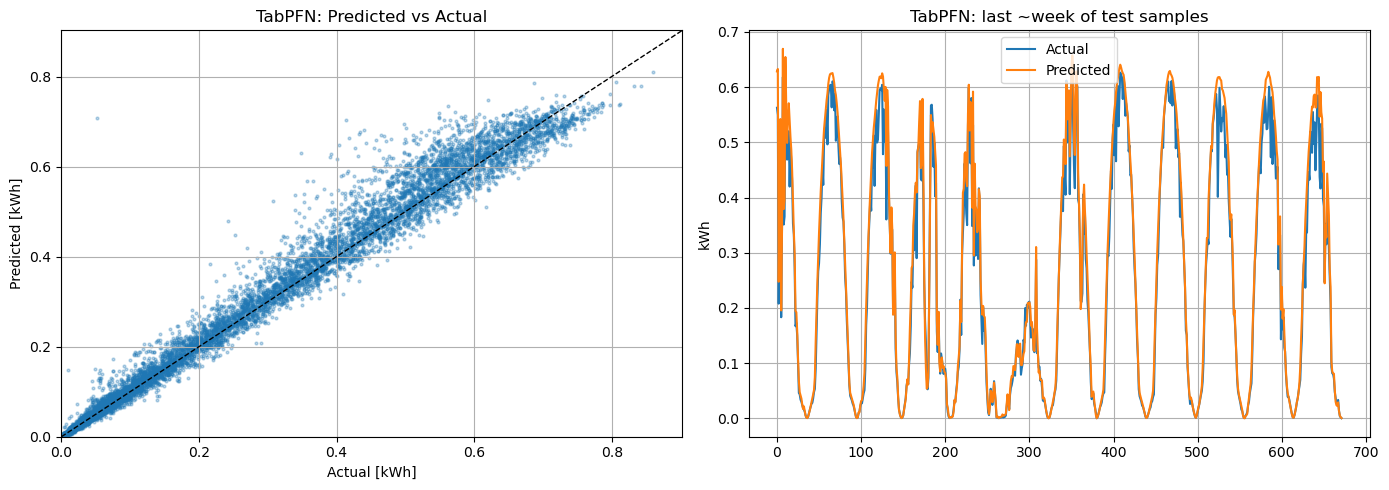

Saved -> ../figure/06_tabpfn_eval.png

Train 12.80s | Inference 6.96s total | 0.033s per 24h


In [8]:
res = evaluate(MODEL_NAME, y_test, y_pred)
res['Train Time']     = train_time
res['Inference Time'] = infer_total
print(f'\nTrain {train_time:.2f}s | Inference {infer_total:.2f}s total | {per24:.3f}s per 24h')

## 7. Save results (predictions + comparison.csv row)

In [9]:
pd.DataFrame({'timestamp': ts_test,
              'actual':    y_test,
              MODEL_KEY:   y_pred}).to_pickle(f'../results/{MODEL_KEY}_predictions.pkl')
print(f'Saved -> ../results/{MODEL_KEY}_predictions.pkl')

comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']
new_rows  = pd.DataFrame([{k: res[k] for k in comp_cols}])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows
combined[comp_cols].to_csv(comp_path, index=False)

print(f'Saved -> {comp_path}\n')
print(combined[comp_cols].to_string(index=False))

Saved -> ../results/tabpfn_predictions.pkl
Saved -> ../results/comparison.csv

                   Model      MAE     RMSE    nRMSE  Train Time  Inference Time
                LightGBM 0.021175 0.034823 0.040512    0.776353        0.014204
        LightGBM (tuned) 0.020895 0.034539 0.040182   48.507317        0.033761
                     MLP 0.020945 0.034464 0.040095    3.505997        0.009781
   Chronos-2 (zero-shot) 0.030790 0.061026 0.070997    0.000000       27.479502
Moirai-1.1-R (zero-shot) 0.188942 0.248844 0.289499    0.000000     1053.703917
 TimesFM-2.5 (zero-shot) 0.034216 0.064202 0.074691    0.000000       17.898780
                  TabPFN 0.019900 0.033954 0.039501   12.799952        6.955939


---
**Outputs**: `../figure/06_tabpfn_eval.png`, `../results/tabpfn_predictions.pkl`, and a headline row
in `../results/comparison.csv`. Because night is dropped with `power > 0`, TabPFN is scored on the
**exact same daytime test rows as the LightGBM / MLP baseline** — a clean tabular-model swap. The
TSFMs (`03`–`05`) instead keep night as sequence context and mask it at evaluation; both routes
score daytime only, so all rows in `comparison.csv` are comparable.